# ISYE 671: Advanced Routing and Combinatorial Models — Computational Lab

**Northern Illinois University — Spring 2026**  
**Instructor: Dr. Ziteng Wang**

---

This notebook is the computational companion to the lecture notes on Advanced Routing Models. We will implement and solve:

1. **Travelling Salesman Problem (TSP)** — MTZ formulation
2. **Assignment relaxation** — to see why subtour elimination matters
3. **Capacitated Vehicle Routing Problem (CVRP)**
4. **VRP with Time Windows (VRPTW)**
5. **Visualization** of tours and routes using NetworkX

All models are implemented in AMPL with Gurobi, following the same patterns from earlier labs.

---
## 0. Environment Setup

Install AMPL and configure the Gurobi solver for Google Colab.

In [1]:
# Install AMPL and solvers
%pip install amplpy --quiet

from amplpy import AMPL, ampl_notebook

# Activate AMPL license (required for Colab)
ampl_notebook(
    modules=["gurobi"],
    license_uuid="YOUR-AMPL-LICENSE-UUID"
)

print("AMPL + Gurobi ready.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 17.3 MB/s eta 0:00:00
Licensed to Bundle #7384.7942 expiring 20260531: ISYE 671 linear optimization and network flows, Prof. Ziteng Wang, Northern Illinois University.
AMPL + Gurobi ready.


In [2]:
# Additional imports for visualization and data handling
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

print("Libraries loaded.")

Libraries loaded.


---
## 1. The Travelling Salesman Problem (TSP)

### 1.1 Problem: Illinois Service Tour

A medical equipment technician based in Chicago must visit hospitals in Rockford, DeKalb, Aurora, Joliet, and Kankakee. Find the minimum-distance tour that visits every city exactly once and returns to Chicago.

We first demonstrate what happens **without** subtour elimination (the assignment relaxation), then solve the full TSP with MTZ constraints.

### 1.2 Step 1 — Assignment Relaxation (No Subtour Elimination)

This model finds the minimum-cost assignment where each city has exactly one incoming and one outgoing arc. Without subtour elimination, the solution may contain disconnected loops.

In [4]:
%%writefile tsp_assignment.mod
# TSP Assignment Relaxation (no subtour elimination)
# Demonstrates why subtour elimination is necessary

set CITIES;
param dist{CITIES, CITIES} >= 0;

# Binary: does the tour go directly from i to j?
var x{i in CITIES, j in CITIES: i != j} binary;

# Minimize total distance
minimize total_distance:
    sum{i in CITIES, j in CITIES: i != j} dist[i,j] * x[i,j];

# Each city is left exactly once
subject to leave_once{i in CITIES}:
    sum{j in CITIES: j != i} x[i,j] = 1;

# Each city is entered exactly once
subject to enter_once{j in CITIES}:
    sum{i in CITIES: i != j} x[i,j] = 1;

Overwriting tsp_assignment.mod


In [6]:
%%writefile tsp_illinois.dat
# Distance matrix for Illinois service tour (miles)

set CITIES := Chicago Rockford DeKalb Aurora Joliet Kankakee;

param dist:
            Chicago  Rockford  DeKalb  Aurora  Joliet  Kankakee :=
Chicago          0       89      66      41      46       60
Rockford        89        0      52      72     108      141
DeKalb          66       52       0      35      80      112
Aurora          41       72      35       0      48       85
Joliet          46      108      80      48       0       42
Kankakee        60      141     112      85      42        0;

Overwriting tsp_illinois.dat


In [7]:
# Solve the assignment relaxation
assignment_model = AMPL()
assignment_model.option["solver"] = "gurobi"
assignment_model.read("tsp_assignment.mod")
assignment_model.readData("tsp_illinois.dat")
assignment_model.solve()

print(f"Solve status: {assignment_model.solve_result}")
print(f"Assignment relaxation distance: {assignment_model.obj['total_distance'].value():.0f} miles")
print()

# Extract and display the arcs used
print("Arcs in assignment solution:")
print("-" * 35)
x_assign = assignment_model.var["x"]
cities = list(assignment_model.set["CITIES"].members())
arcs = []
for i in cities:
    for j in cities:
        if i != j and x_assign[i, j].value() > 0.5:
            arcs.append((i, j))
            print(f"  {i} → {j}")

# Check for subtours
def find_subtours(arcs, cities):
    """Identify all subtours in a set of arcs."""
    next_city = {a[0]: a[1] for a in arcs}
    visited = set()
    tours = []
    for start in cities:
        if start not in visited:
            tour = []
            current = start
            while current not in visited:
                visited.add(current)
                tour.append(current)
                current = next_city.get(current)
                if current is None:
                    break
            if tour:
                tours.append(tour)
    return tours

subtours = find_subtours(arcs, cities)
print(f"\nNumber of subtours: {len(subtours)}")
for idx, tour in enumerate(subtours):
    print(f"  Subtour {idx+1}: {' → '.join(tour)} → {tour[0]}")

if len(subtours) > 1:
    print("\n⚠️  The assignment solution has SUBTOURS — it is NOT a valid TSP tour!")
    print("   This is why we need subtour elimination constraints.")
else:
    print("\n✓ The assignment solution happens to be a valid tour (lucky case).")
    print("  For larger instances, subtours almost always occur without elimination constraints.")

Gurobi 13.0.0: Gurobi 13.0.0: optimal solution; objective 270
9 simplex iterations
1 branching node
Solve status: solved
Assignment relaxation distance: 270 miles

Arcs in assignment solution:
-----------------------------------
  Chicago → Aurora
  Rockford → DeKalb
  DeKalb → Rockford
  Aurora → Chicago
  Joliet → Kankakee
  Kankakee → Joliet

Number of subtours: 3
  Subtour 1: Chicago → Aurora → Chicago
  Subtour 2: Rockford → DeKalb → Rockford
  Subtour 3: Joliet → Kankakee → Joliet

⚠️  The assignment solution has SUBTOURS — it is NOT a valid TSP tour!
   This is why we need subtour elimination constraints.


### 1.3 Step 2 — Full TSP with MTZ Subtour Elimination

Now we add the Miller–Tucker–Zemlin (MTZ) constraints. These introduce position variables $u_i$ that enforce a sequential ordering, preventing subtours.

**Key constraint:** If the tour goes from $i$ to $j$ (i.e., $x_{ij} = 1$), then $u_j \geq u_i + 1$, enforcing that $j$ comes after $i$ in the tour sequence.

In [ ]:
%%writefile tsp_mtz.mod
# Travelling Salesman Problem — MTZ Formulation
# Complete model with subtour elimination

set CITIES ordered;
param n := card(CITIES);
param dist{CITIES, CITIES} >= 0;

# Identify the depot (first city in the ordered set)
param depot symbolic := first(CITIES);

# Binary: does the tour travel directly from i to j?
var x{i in CITIES, j in CITIES: i != j} binary;

# Position variables for MTZ (only for non-depot cities)
var u{i in CITIES: i != depot} >= 1, <= n - 1;

# Minimize total tour distance
minimize total_distance:
    sum{i in CITIES, j in CITIES: i != j} dist[i,j] * x[i,j];

# Each city is left exactly once
subject to leave_once{i in CITIES}:
    sum{j in CITIES: j != i} x[i,j] = 1;

# Each city is entered exactly once
subject to enter_once{j in CITIES}:
    sum{i in CITIES: i != j} x[i,j] = 1;

# MTZ subtour elimination constraints
# If x[i,j] = 1, then u[j] >= u[i] + 1
subject to mtz{i in CITIES, j in CITIES: i != j and i != depot and j != depot}:
    u[i] - u[j] + n * x[i,j] <= n - 1;

Writing tsp_mtz.mod


In [ ]:
# Solve the full TSP
tsp_model = AMPL()
tsp_model.option["solver"] = "gurobi"
tsp_model.option["gurobi_options"] = "outlev=1 timelimit=120"
tsp_model.read("tsp_mtz.mod")
tsp_model.readData("tsp_illinois.dat")
tsp_model.solve()

print(f"\nSolve status: {tsp_model.solve_result}")
print(f"Optimal tour distance: {tsp_model.obj['total_distance'].value():.0f} miles")
print()

# Extract the optimal tour
x_tsp = tsp_model.var["x"]
cities_tsp = list(tsp_model.set["CITIES"].members())
tsp_arcs = []
for i in cities_tsp:
    for j in cities_tsp:
        if i != j and x_tsp[i, j].value() > 0.5:
            tsp_arcs.append((i, j))

# Build the tour sequence starting from Chicago
next_city = {a[0]: a[1] for a in tsp_arcs}
tour = ["Chicago"]
current = "Chicago"
while next_city[current] != "Chicago":
    current = next_city[current]
    tour.append(current)
tour.append("Chicago")

print("Optimal tour:")
print("  " + " → ".join(tour))

# Print position variables
print("\nPosition variables (u):")
print(f"  {'City':<12} {'Position':>10}")
print("  " + "-" * 22)
u_tsp = tsp_model.var["u"]
for city in cities_tsp:
    if city != "Chicago":
        print(f"  {city:<12} {u_tsp[city].value():>10.0f}")

Gurobi 13.0.0: Set parameter LogToConsole to value 1
  tech:outlev = 1
Set parameter TimeLimit to value 120
  lim:time = 120

AMPL MP initial flat model has 35 variables (0 integer, 30 binary);
Objectives: 1 linear; 
Constraints:  32 linear;

AMPL MP final model has 35 variables (0 integer, 30 binary);
Objectives: 1 linear; 
Constraints:  32 linear;


Set parameter InfUnbdInfo to value 1
Gurobi Optimizer version 13.0.0 build v13.0.0rc1 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Non-default parameters:
TimeLimit  120
InfUnbdInfo  1

Optimize a model with 32 rows, 35 columns and 120 nonzeros (Min)
Model fingerprint: 0x6517f817
Model has 30 linear objective coefficients
Variable types: 5 continuous, 30 integer (0 binary)
Coefficient statistics:
  Matrix range     [1e+00, 6e+00]
  Objective range  [4e+01, 1e+02]
  Bounds range     [1e+00, 5e+00]
  R

### 1.4 Visualize the TSP Tour

We plot the cities on a map-like layout and draw the optimal tour.

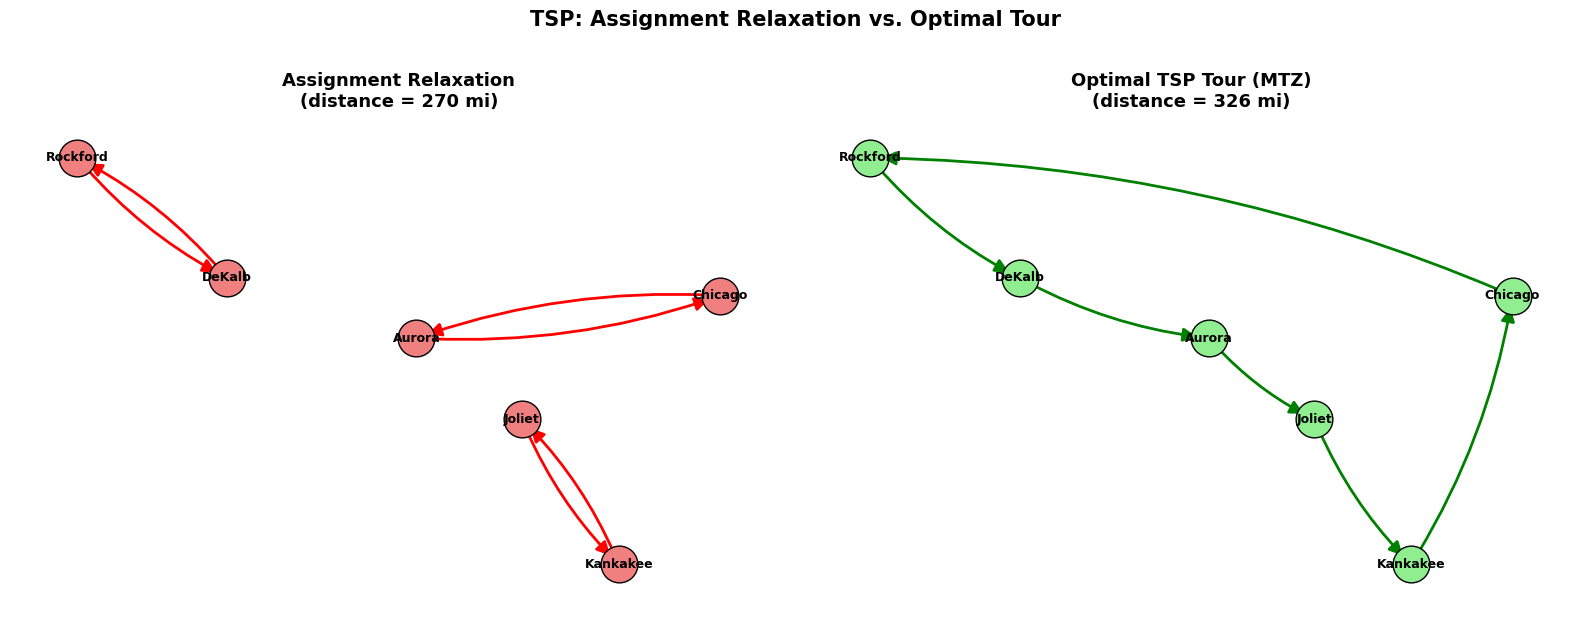

In [ ]:
# Approximate coordinates for Illinois cities (lon, lat mapped to x, y)
city_coords = {
    "Chicago":  (87.63, 41.88),
    "Rockford": (89.09, 42.27),
    "DeKalb":   (88.75, 41.93),
    "Aurora":   (88.32, 41.76),
    "Joliet":   (88.08, 41.53),
    "Kankakee": (87.86, 41.12)
}

# Use negative longitude for correct east-west orientation
pos = {c: (-lon, lat) for c, (lon, lat) in city_coords.items()}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Assignment relaxation
ax1 = axes[0]
G1 = nx.DiGraph()
G1.add_nodes_from(cities)
G1.add_edges_from(arcs)
nx.draw_networkx_nodes(G1, pos, ax=ax1, node_color='lightcoral', node_size=700, edgecolors='black')
nx.draw_networkx_labels(G1, pos, ax=ax1, font_size=9, font_weight='bold')
nx.draw_networkx_edges(G1, pos, ax=ax1, edge_color='red', arrows=True,
                       arrowsize=20, width=2, connectionstyle='arc3,rad=0.1')
ax1.set_title(f"Assignment Relaxation\n(distance = {assignment_model.obj['total_distance'].value():.0f} mi)",
              fontsize=13, fontweight='bold')
ax1.axis('off')

# Plot 2: Optimal TSP tour
ax2 = axes[1]
G2 = nx.DiGraph()
G2.add_nodes_from(cities_tsp)
G2.add_edges_from(tsp_arcs)
nx.draw_networkx_nodes(G2, pos, ax=ax2, node_color='lightgreen', node_size=700, edgecolors='black')
nx.draw_networkx_labels(G2, pos, ax=ax2, font_size=9, font_weight='bold')
nx.draw_networkx_edges(G2, pos, ax=ax2, edge_color='green', arrows=True,
                       arrowsize=20, width=2, connectionstyle='arc3,rad=0.1')
ax2.set_title(f"Optimal TSP Tour (MTZ)\n(distance = {tsp_model.obj['total_distance'].value():.0f} mi)",
              fontsize=13, fontweight='bold')
ax2.axis('off')

plt.suptitle("TSP: Assignment Relaxation vs. Optimal Tour", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 1.5 Scaling Experiment: How Does TSP Grow?

Let's see how solve time grows as we add cities. We'll generate random TSP instances and track solver performance.

In [ ]:
import time

def solve_random_tsp(n, seed=42):
    """Generate and solve a random n-city TSP using MTZ formulation."""
    np.random.seed(seed)
    coords = np.random.rand(n, 2) * 100  # cities in [0,100] x [0,100]

    model = AMPL()
    model.option["solver"] = "gurobi"
    model.option["gurobi_options"] = "outlev=0 timelimit=60"
    model.read("tsp_mtz.mod")

    # Load data programmatically
    city_names = [f"C{i}" for i in range(n)]
    model.set["CITIES"] = city_names

    dist_param = model.param["dist"]
    for i in range(n):
        for j in range(n):
            d = np.sqrt(np.sum((coords[i] - coords[j])**2))
            dist_param[city_names[i], city_names[j]] = round(d, 1)

    start = time.time()
    model.solve()
    elapsed = time.time() - start

    obj = model.obj["total_distance"].value()
    status = model.solve_result
    return obj, elapsed, status

print(f"{'Cities':>6}  {'Distance':>10}  {'Time (s)':>10}  {'Status'}")
print("-" * 45)

for n in [6, 8, 10, 15, 20, 25, 30]:
    obj, elapsed, status = solve_random_tsp(n)
    print(f"{n:>6}  {obj:>10.1f}  {elapsed:>10.2f}  {status}")

print("\n💡 Observation: TSP solve time grows rapidly with problem size.")
print("   For n > 30–50, heuristics or specialized TSP solvers are needed.")

Cities    Distance    Time (s)  Status
---------------------------------------------
Gurobi 13.0.0:   tech:outlev = 0
  lim:time = 60
Gurobi 13.0.0: optimal solution; objective 241
31 simplex iterations
1 branching node
     6       241.0        0.02  solved
Gurobi 13.0.0:   tech:outlev = 0
  lim:time = 60
Gurobi 13.0.0: optimal solution; objective 277.2
56 simplex iterations
1 branching node
     8       277.2        0.02  solved
Gurobi 13.0.0:   tech:outlev = 0
  lim:time = 60
Gurobi 13.0.0: optimal solution; objective 290.2
77 simplex iterations
1 branching node
    10       290.2        0.06  solved
Gurobi 13.0.0:   tech:outlev = 0
  lim:time = 60
Gurobi 13.0.0: optimal solution; objective 320.5
228 simplex iterations
1 branching node
    15       320.5        0.08  solved
Gurobi 13.0.0:   tech:outlev = 0
  lim:time = 60
Gurobi 13.0.0: optimal solution; objective 386.5
864 simplex iterations
10 branching nodes
    20       386.5        0.42  solved
Gurobi 13.0.0:   tech:outlev = 0


---
## 2. Capacitated Vehicle Routing Problem (CVRP)

### 2.1 Problem: Northern Illinois Food Bank Delivery

A food bank (depot) operates $K = 3$ trucks, each with capacity $Q = 2000$ lbs. There are 10 partner pantries with known demands and locations. Find the minimum-distance set of routes.

In [ ]:
%%writefile cvrp.mod
# Capacitated Vehicle Routing Problem (CVRP)
# Multiple vehicles, single depot, capacity constraints

set NODES ordered;                       # All nodes (depot + customers)
set CUSTOMERS within NODES;              # Customer nodes only
set VEHICLES;                            # Set of vehicles

param depot symbolic := first(NODES);    # Depot is the first node
param n := card(NODES);
param dist{NODES, NODES} >= 0;           # Distance matrix
param demand{NODES} >= 0;                # Customer demands (depot demand = 0)
param capacity >= 0;                     # Vehicle capacity

# Binary: vehicle k travels from i to j
var x{i in NODES, j in NODES, k in VEHICLES: i != j} binary;

# Position variables for MTZ subtour elimination (per vehicle)
var u{i in CUSTOMERS, k in VEHICLES} >= 0, <= card(CUSTOMERS);

# Minimize total distance
minimize total_distance:
    sum{i in NODES, j in NODES, k in VEHICLES: i != j}
        dist[i,j] * x[i,j,k];

# Each customer is visited by exactly one vehicle
subject to visit_once{i in CUSTOMERS}:
    sum{j in NODES, k in VEHICLES: j != i} x[i,j,k] = 1;

# Each vehicle leaves the depot at most once
subject to leave_depot{k in VEHICLES}:
    sum{j in CUSTOMERS} x[depot,j,k] <= 1;

# Each vehicle returns to the depot at most once
subject to return_depot{k in VEHICLES}:
    sum{i in CUSTOMERS} x[i,depot,k] <= 1;

# Flow conservation: if vehicle k enters node j, it must leave
subject to flow_balance{j in CUSTOMERS, k in VEHICLES}:
    sum{i in NODES: i != j} x[i,j,k] = sum{i in NODES: i != j} x[j,i,k];

# Vehicle capacity
subject to cap{k in VEHICLES}:
    sum{i in CUSTOMERS, j in NODES: j != i} demand[i] * x[i,j,k] <= capacity;

# MTZ subtour elimination (per vehicle)
subject to mtz_vrp{i in CUSTOMERS, j in CUSTOMERS, k in VEHICLES: i != j}:
    u[i,k] - u[j,k] + card(CUSTOMERS) * x[i,j,k] <= card(CUSTOMERS) - 1;

Writing cvrp.mod


In [ ]:
%%writefile cvrp_foodbank.dat
# Northern Illinois Food Bank — 10 pantries + 1 depot
# Coordinates are approximate (x, y in miles from depot)

set NODES := Depot P1 P2 P3 P4 P5 P6 P7 P8 P9 P10;
set CUSTOMERS := P1 P2 P3 P4 P5 P6 P7 P8 P9 P10;
set VEHICLES := Truck1 Truck2 Truck3;

param capacity := 2000;

param demand :=
    Depot   0
    P1    450
    P2    300
    P3    550
    P4    200
    P5    400
    P6    350
    P7    600
    P8    250
    P9    500
    P10   350;

# Distance matrix (symmetric, in miles)
param dist default 999 :
          Depot  P1   P2   P3   P4   P5   P6   P7   P8   P9   P10 :=
Depot       0    12   18   25   8    30   22   35   15   28   20
P1         12     0   10   20   15   25   18   30   22   32   16
P2         18    10    0   12   22   20   14   28   25   30   18
P3         25    20   12    0   30   15   10   20   32   22   24
P4          8    15   22   30    0   35   28   40   10   32   25
P5         30    25   20   15   35    0    8   12   38   18   28
P6         22    18   14   10   28    8    0   15   30   16   22
P7         35    30   28   20   40   12   15    0   42   10   30
P8         15    22   25   32   10   38   30   42    0   35   20
P9         28    32   30   22   32   18   16   10   35    0   26
P10        20    16   18   24   25   28   22   30   20   26    0;

Writing cvrp_foodbank.dat


In [ ]:
# Solve the CVRP
cvrp_model = AMPL()
cvrp_model.option["solver"] = "gurobi"
cvrp_model.option["gurobi_options"] = "outlev=1 timelimit=300"
cvrp_model.read("cvrp.mod")
cvrp_model.readData("cvrp_foodbank.dat")
cvrp_model.solve()

print(f"\nSolve status: {cvrp_model.solve_result}")
print(f"Total distance: {cvrp_model.obj['total_distance'].value():.0f} miles")

Gurobi 13.0.0: Set parameter LogToConsole to value 1
  tech:outlev = 1
Set parameter TimeLimit to value 300
  lim:time = 300

AMPL MP initial flat model has 360 variables (0 integer, 330 binary);
Objectives: 1 linear; 
Constraints:  319 linear;

AMPL MP final model has 360 variables (0 integer, 330 binary);
Objectives: 1 linear; 
Constraints:  319 linear;


Set parameter InfUnbdInfo to value 1
Gurobi Optimizer version 13.0.0 build v13.0.0rc1 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Non-default parameters:
TimeLimit  300
InfUnbdInfo  1

Optimize a model with 319 rows, 360 columns and 2070 nonzeros (Min)
Model fingerprint: 0x8c64f11b
Model has 330 linear objective coefficients
Variable types: 30 continuous, 330 integer (0 binary)
Coefficient statistics:
  Matrix range     [1e+00, 6e+02]
  Objective range  [8e+00, 4e+01]
  Bounds range     [1e+00

In [ ]:
# Extract and display routes for each vehicle
x_vrp = cvrp_model.var["x"]
nodes = list(cvrp_model.set["NODES"].members())
vehicles = list(cvrp_model.set["VEHICLES"].members())
demand_param = cvrp_model.param["demand"]
dist_param = cvrp_model.param["dist"]

print("\n" + "=" * 65)
print("VEHICLE ROUTING SOLUTION")
print("=" * 65)

routes = {}  # vehicle -> list of arcs
for k in vehicles:
    vehicle_arcs = []
    for i in nodes:
        for j in nodes:
            if i != j and x_vrp[i, j, k].value() > 0.5:
                vehicle_arcs.append((i, j))
    routes[k] = vehicle_arcs

for k in vehicles:
    if not routes[k]:
        print(f"\n{k}: Not used")
        continue

    # Build route sequence from depot
    next_node = {a[0]: a[1] for a in routes[k]}
    if "Depot" not in next_node:
        continue
    route_seq = ["Depot"]
    current = "Depot"
    total_demand = 0
    route_dist = 0
    while next_node.get(current) and next_node[current] != "Depot":
        nxt = next_node[current]
        route_dist += dist_param[current, nxt]
        current = nxt
        route_seq.append(current)
        total_demand += demand_param[current]
    if current != "Depot":
        route_dist += dist_param[current, "Depot"]
    route_seq.append("Depot")

    print(f"\n{k}:")
    print(f"  Route:    {' → '.join(route_seq)}")
    print(f"  Load:     {total_demand:.0f} / 2000 lbs ({total_demand/2000*100:.0f}% capacity)")
    print(f"  Distance: {route_dist:.0f} miles")

print(f"\n{'─' * 65}")
print(f"Total distance: {cvrp_model.obj['total_distance'].value():.0f} miles")
print(f"Total demand served: {sum(demand_param[c] for c in list(cvrp_model.set['CUSTOMERS'].members())):.0f} lbs")


VEHICLE ROUTING SOLUTION

Truck1: Not used

Truck2:
  Route:    Depot → P1 → P5 → P7 → P9 → Depot
  Load:     1950 / 2000 lbs (98% capacity)
  Distance: 87 miles

Truck3:
  Route:    Depot → P4 → P8 → P10 → P6 → P3 → P2 → Depot
  Load:     2000 / 2000 lbs (100% capacity)
  Distance: 100 miles

─────────────────────────────────────────────────────────────────
Total distance: 187 miles
Total demand served: 3950 lbs


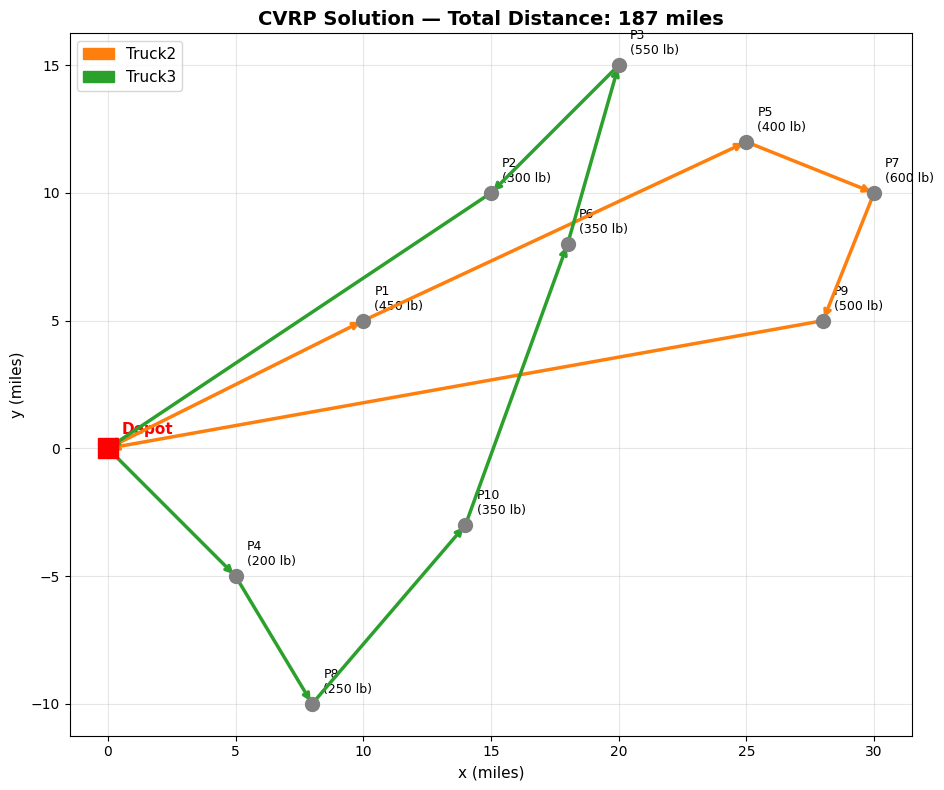

In [ ]:
# Visualize the CVRP solution
vrp_coords = {
    "Depot": (0, 0), "P1": (10, 5), "P2": (15, 10), "P3": (20, 15),
    "P4": (5, -5), "P5": (25, 12), "P6": (18, 8), "P7": (30, 10),
    "P8": (8, -10), "P9": (28, 5), "P10": (14, -3)
}

colors = ['tab:blue', 'tab:orange', 'tab:green']

fig, ax = plt.subplots(figsize=(12, 8))

# Draw depot
ax.plot(*vrp_coords["Depot"], 's', color='red', markersize=15, zorder=5)
ax.annotate("Depot", vrp_coords["Depot"], textcoords="offset points",
            xytext=(10, 10), fontsize=11, fontweight='bold', color='red')

# Draw customers
for c in list(cvrp_model.set['CUSTOMERS'].members()):
    ax.plot(*vrp_coords[c], 'o', color='gray', markersize=10, zorder=4)
    d = demand_param[c]
    ax.annotate(f"{c}\n({d:.0f} lb)", vrp_coords[c], textcoords="offset points",
                xytext=(8, 8), fontsize=9)

# Draw routes
legend_handles = []
for idx, k in enumerate(vehicles):
    if not routes[k]:
        continue
    for (i, j) in routes[k]:
        xi, yi = vrp_coords[i]
        xj, yj = vrp_coords[j]
        ax.annotate("", xy=(xj, yj), xytext=(xi, yi),
                    arrowprops=dict(arrowstyle='->', color=colors[idx], lw=2.5))
    legend_handles.append(mpatches.Patch(color=colors[idx], label=k))

ax.legend(handles=legend_handles, fontsize=11, loc='upper left')
ax.set_title(f"CVRP Solution — Total Distance: {cvrp_model.obj['total_distance'].value():.0f} miles",
             fontsize=14, fontweight='bold')
ax.set_xlabel("x (miles)", fontsize=11)
ax.set_ylabel("y (miles)", fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

---
## 3. VRP with Time Windows (VRPTW)

We extend the CVRP by adding time window constraints. Each customer must be served within a specified time window $[a_i, b_i]$. A vehicle arriving early must wait.

In [ ]:
%%writefile vrptw.mod
# Vehicle Routing Problem with Time Windows (VRPTW)

set NODES ordered;
set CUSTOMERS within NODES;
set VEHICLES;

param depot symbolic := first(NODES);
param dist{NODES, NODES} >= 0;
param demand{NODES} >= 0;
param capacity >= 0;

# Time window parameters
param earliest{NODES} >= 0;        # Earliest service start time
param latest{NODES} >= 0;          # Latest service start time
param service_time{NODES} >= 0;    # Time spent at each node
param travel_time{NODES, NODES} >= 0;  # Travel time between nodes

param M := 1000;  # Big-M for time linking

# Binary: vehicle k travels from i to j
var x{i in NODES, j in NODES, k in VEHICLES: i != j} binary;

# Continuous: time vehicle k starts service at node i
var t{NODES, VEHICLES} >= 0;

# Minimize total distance
minimize total_distance:
    sum{i in NODES, j in NODES, k in VEHICLES: i != j}
        dist[i,j] * x[i,j,k];

# Each customer visited exactly once
subject to visit_once{i in CUSTOMERS}:
    sum{j in NODES, k in VEHICLES: j != i} x[i,j,k] = 1;

# Vehicle leaves depot at most once
subject to leave_depot{k in VEHICLES}:
    sum{j in CUSTOMERS} x[depot,j,k] <= 1;

# Vehicle returns to depot
subject to return_depot{k in VEHICLES}:
    sum{i in CUSTOMERS} x[i,depot,k] <= 1;

# Flow conservation
subject to flow_balance{j in CUSTOMERS, k in VEHICLES}:
    sum{i in NODES: i != j} x[i,j,k] = sum{i in NODES: i != j} x[j,i,k];

# Capacity
subject to cap{k in VEHICLES}:
    sum{i in CUSTOMERS, j in NODES: j != i} demand[i] * x[i,j,k] <= capacity;

# Time windows: service must start within the window
subject to tw_early{i in CUSTOMERS, k in VEHICLES}:
    t[i,k] >= earliest[i] * (sum{j in NODES: j != i} x[i,j,k]);

subject to tw_late{i in CUSTOMERS, k in VEHICLES}:
    t[i,k] <= latest[i] * (sum{j in NODES: j != i} x[i,j,k])
              + M * (1 - sum{j in NODES: j != i} x[i,j,k]);

# Time precedence: if vehicle k goes from i to j, arrival at j >= departure from i
subject to time_link{i in NODES, j in CUSTOMERS, k in VEHICLES: i != j}:
    t[i,k] + service_time[i] + travel_time[i,j] - M * (1 - x[i,j,k]) <= t[j,k];

Writing vrptw.mod


In [ ]:
%%writefile vrptw_foodbank.dat
# VRPTW data: Food bank with morning and afternoon delivery windows
# Times are in minutes from 7:00 AM (e.g., 60 = 8:00 AM)

set NODES := Depot P1 P2 P3 P4 P5 P6 P7 P8 P9 P10;
set CUSTOMERS := P1 P2 P3 P4 P5 P6 P7 P8 P9 P10;
set VEHICLES := Truck1 Truck2 Truck3;

param capacity := 2000;

param:         demand  earliest  latest  service_time :=
Depot            0        0       600       0
P1             450       60       180      15
P2             300       60       180      15
P3             550      120       240      20
P4             200       60       180      10
P5             400      180       360      15
P6             350      120       300      15
P7             600      180       360      20
P8             250       60       180      10
P9             500      240       420      20
P10            350      180       360      15;

# Distance matrix (same as CVRP)
param dist default 999 :
          Depot  P1   P2   P3   P4   P5   P6   P7   P8   P9   P10 :=
Depot       0    12   18   25   8    30   22   35   15   28   20
P1         12     0   10   20   15   25   18   30   22   32   16
P2         18    10    0   12   22   20   14   28   25   30   18
P3         25    20   12    0   30   15   10   20   32   22   24
P4          8    15   22   30    0   35   28   40   10   32   25
P5         30    25   20   15   35    0    8   12   38   18   28
P6         22    18   14   10   28    8    0   15   30   16   22
P7         35    30   28   20   40   12   15    0   42   10   30
P8         15    22   25   32   10   38   30   42    0   35   20
P9         28    32   30   22   32   18   16   10   35    0   26
P10        20    16   18   24   25   28   22   30   20   26    0;

# Travel time (assume 1 mile = 2 minutes)
param travel_time default 999 :
          Depot  P1   P2   P3   P4   P5   P6   P7   P8   P9   P10 :=
Depot       0    24   36   50   16   60   44   70   30   56   40
P1         24     0   20   40   30   50   36   60   44   64   32
P2         36    20    0   24   44   40   28   56   50   60   36
P3         50    40   24    0   60   30   20   40   64   44   48
P4         16    30   44   60    0   70   56   80   20   64   50
P5         60    50   40   30   70    0   16   24   76   36   56
P6         44    36   28   20   56   16    0   30   60   32   44
P7         70    60   56   40   80   24   30    0   84   20   60
P8         30    44   50   64   20   76   60   84    0   70   40
P9         56    64   60   44   64   36   32   20   70    0   52
P10        40    32   36   48   50   56   44   60   40   52    0;

Writing vrptw_foodbank.dat


In [ ]:
# Solve the VRPTW
vrptw_model = AMPL()
vrptw_model.option["solver"] = "gurobi"
vrptw_model.option["gurobi_options"] = "outlev=1 timelimit=300"
vrptw_model.read("vrptw.mod")
vrptw_model.readData("vrptw_foodbank.dat")
vrptw_model.solve()

print(f"\nSolve status: {vrptw_model.solve_result}")
print(f"Total distance: {vrptw_model.obj['total_distance'].value():.0f} miles")

Gurobi 13.0.0: Set parameter LogToConsole to value 1
  tech:outlev = 1
Set parameter TimeLimit to value 300
  lim:time = 300

AMPL MP initial flat model has 363 variables (0 integer, 330 binary);
Objectives: 1 linear; 
Constraints:  409 linear;

AMPL MP final model has 363 variables (0 integer, 330 binary);
Objectives: 1 linear; 
Constraints:  409 linear;


Set parameter InfUnbdInfo to value 1
Gurobi Optimizer version 13.0.0 build v13.0.0rc1 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Non-default parameters:
TimeLimit  300
InfUnbdInfo  1

Optimize a model with 409 rows, 363 columns and 2820 nonzeros (Min)
Model fingerprint: 0x01b42d01
Model has 330 linear objective coefficients
Variable types: 33 continuous, 330 integer (0 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+03]
  Objective range  [8e+00, 4e+01]
  Bounds range     [1e+00

In [ ]:
# Extract and display VRPTW routes with schedules
x_tw = vrptw_model.var["x"]
t_tw = vrptw_model.var["t"]
nodes_tw = list(vrptw_model.set["NODES"].members())
vehs_tw = list(vrptw_model.set["VEHICLES"].members())
earliest_p = vrptw_model.param["earliest"]
latest_p = vrptw_model.param["latest"]
demand_tw = vrptw_model.param["demand"]

def mins_to_time(mins):
    """Convert minutes from 7:00 AM to time string."""
    h = 7 + int(mins) // 60
    m = int(mins) % 60
    ampm = "AM" if h < 12 else "PM"
    if h > 12: h -= 12
    return f"{h}:{m:02d} {ampm}"

print("\n" + "=" * 75)
print("VRPTW SOLUTION — ROUTES WITH SCHEDULES")
print("=" * 75)

for k in vehs_tw:
    tw_arcs = []
    for i in nodes_tw:
        for j in nodes_tw:
            if i != j and x_tw[i, j, k].value() > 0.5:
                tw_arcs.append((i, j))
    if not tw_arcs:
        print(f"\n{k}: Not used")
        continue

    next_n = {a[0]: a[1] for a in tw_arcs}
    if "Depot" not in next_n:
        continue

    route_seq = ["Depot"]
    current = "Depot"
    total_load = 0
    while next_n.get(current) and next_n[current] != "Depot":
        current = next_n[current]
        route_seq.append(current)
        total_load += demand_tw[current]
    route_seq.append("Depot")

    print(f"\n{k}: {' → '.join(route_seq)}")
    print(f"  Load: {total_load:.0f} / 2000 lbs")
    print(f"  {'Stop':<8} {'Arrive':>10} {'Window':>20} {'Demand':>8}")
    print(f"  {'─'*50}")
    for stop in route_seq[1:-1]:  # skip depot
        arrive = t_tw[stop, k].value()
        window = f"[{mins_to_time(earliest_p[stop])}, {mins_to_time(latest_p[stop])}]"
        print(f"  {stop:<8} {mins_to_time(arrive):>10} {window:>20} {demand_tw[stop]:>8.0f}")

### 3.1 Comparing CVRP vs. VRPTW

Time windows restrict feasible routes, typically increasing total distance.

In [ ]:
cvrp_dist = cvrp_model.obj['total_distance'].value()
vrptw_dist = vrptw_model.obj['total_distance'].value()
increase = (vrptw_dist - cvrp_dist) / cvrp_dist * 100

print("Impact of Time Windows on Routing")
print("=" * 40)
print(f"CVRP distance:   {cvrp_dist:>8.0f} miles")
print(f"VRPTW distance:  {vrptw_dist:>8.0f} miles")
print(f"Increase:        {increase:>8.1f}%")
print()
print("💡 Time windows constrain which customers can be grouped together,")
print("   often forcing longer routes to respect scheduling requirements.")

---
## 4. Student Exercises

### Exercise 1: Larger TSP

Add two more cities to the Illinois service tour: **Champaign** and **Bloomington**. Use the distance data below and solve the 8-city TSP. Compare the solve time to the 6-city instance.

In [ ]:
%%writefile tsp_illinois_8.dat
# Extended Illinois service tour — 8 cities

set CITIES := Chicago Rockford DeKalb Aurora Joliet Kankakee Champaign Bloomington;

param dist:
                Chicago Rockford DeKalb Aurora Joliet Kankakee Champaign Bloomington :=
Chicago              0      89     66     41     46      60      135       130
Rockford            89       0     52     72    108     141      185       120
DeKalb              66      52      0     35     80     112      150        95
Aurora              41      72     35      0     48      85      155       110
Joliet              46     108     80     48      0      42      115       120
Kankakee            60     141    112     85     42       0       80       125
Champaign          135     185    150    155    115      80        0        50
Bloomington        130     120     95    110    120     125       50         0;

In [ ]:
# TODO: Solve the 8-city TSP using the tsp_mtz.mod model
# 1. Create an AMPL instance
# 2. Load the model and data
# 3. Solve and report the optimal tour
# 4. Compare solve time to the 6-city case

# Your code here:


### Exercise 2: Effect of Capacity on VRP

Re-solve the food bank CVRP with truck capacity reduced to 1500 lbs. What happens to the total distance? Do you need more trucks?

In [ ]:
# TODO: Modify the CVRP to use capacity = 1500 and add a 4th truck if needed
# Hint: You can load the model and override the capacity parameter:
#   model.param["capacity"] = 1500

# Your code here:


### Exercise 3: Asymmetric TSP

In many real routing problems, the distance from $i$ to $j$ differs from $j$ to $i$ (e.g., one-way streets, elevation changes). Modify the Illinois TSP data so that the distance matrix is asymmetric — for example, add 10% to all northbound distances and subtract 10% from southbound distances. Solve and compare to the symmetric case.

In [ ]:
# TODO: Create an asymmetric distance matrix and solve the TSP
# Hint: Use the Python API to load data programmatically

# Your code here:
